In [ ]:
import pandas as pd
"""OLFACTION BASE"""
def calculate_combined_odor_statistics():
    first_path = "/home/henrich/Documents/aromaLLM/data/curated_PrimaryOdor.csv"
    second_path = "/home/henrich/Documents/aromaLLM/data/curated_SubOdor.csv"
    df1 = pd.read_csv(first_path)
    df2 = pd.read_csv(second_path)
    
    all_molecules = df1['standardized_smiles'].tolist() + df2['standardized_smiles'].tolist()
    
    all_labels = []
    for df in [df1, df2]:
        label_cols = [col for col in df.columns if col.startswith('odor_')]
        for col in label_cols:
            all_labels.extend(df[col].dropna().tolist())
            
    total_molecules_count = len(all_molecules)
    unique_molecules_count = len(set(all_molecules))
    total_label_assignments = len(all_labels)
    unique_labels_count = len(set(all_labels))
    mean_labels_per_entry = total_label_assignments / total_molecules_count
    
    print("\n--- Combined Dataset Statistics ---")
    print(f"Total Molecule Records (Summed): {total_molecules_count}")
    print(f"Unique Molecules Across Both: {unique_molecules_count}")
    print(f"Total Label Assignments: {total_label_assignments}")
    print(f"Unique Labels: {unique_labels_count}")
    print(f"Mean Labels per Molecule Record: {mean_labels_per_entry:.2f}")

if __name__ == "__main__":
    calculate_combined_odor_statistics()


--- Combined Dataset Statistics ---
Total Molecule Records (Summed): 6848
Unique Molecules Across Both: 3424
Total Label Assignments: 54150
Unique Labels: 538
Mean Labels per Molecule Record: 7.91


In [3]:
import pandas as pd
"""LITERATURE"""
def calcular_estatisticas_dataset_binario(caminho_arquivo):
    df = pd.read_csv(caminho_arquivo)
    
    coluna_molecula = 'nonStereoSMILES'
    colunas_rotulos = df.columns[2:]
    
    total_moleculas = df[coluna_molecula].nunique()
    total_atribuicoes = df[colunas_rotulos].sum().sum()
    rotulos_unicos = len(colunas_rotulos)
    media_por_molecula = total_atribuicoes / total_moleculas
    
    print("--- Estatísticas do Dataset ---")
    print(f"Total de moléculas: {total_moleculas}")
    print(f"Total de atribuições de rótulos: {total_atribuicoes}")
    print(f"Rótulos únicos: {rotulos_unicos}")
    print(f"Média de rótulos por molécula: {media_por_molecula:.2f}")

if __name__ == "__main__":
    calcular_estatisticas_dataset_binario("/home/henrich/Documents/aromaLLM/data/Multi-Labelled_Smiles_Odors_dataset.csv")

--- Estatísticas do Dataset ---
Total de moléculas: 4983
Total de atribuições de rótulos: 24312
Rótulos únicos: 138
Média de rótulos por molécula: 4.88


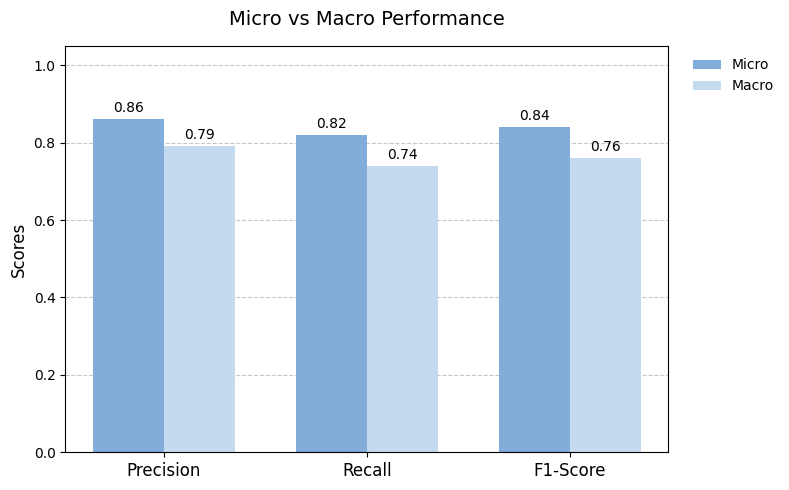

In [2]:
import matplotlib.pyplot as plt
import numpy as np

# Extracted data from the original chart
categories = ['Precision', 'Recall', 'F1-Score']
micro_scores = [0.86, 0.82, 0.84]
macro_scores = [0.79, 0.74, 0.76]

x = np.arange(len(categories))  # Label locations
width = 0.35  # Width of the bars

# Create the figure and axis
fig, ax = plt.subplots(figsize=(8, 5))

# Define the new pastel blue colors
dark_pastel_blue = '#82ACD9'
light_pastel_blue = '#C4DAEE'

# Plot the bars
rects1 = ax.bar(x - width/2, micro_scores, width, label='Micro', color=dark_pastel_blue)
rects2 = ax.bar(x + width/2, macro_scores, width, label='Macro', color=light_pastel_blue)

# Add formatting and labels
ax.set_ylabel('Scores', fontsize=12)
ax.set_title('Micro vs Macro Performance', pad=15, fontsize=14)
ax.set_xticks(x)
ax.set_xticklabels(categories, fontsize=12)

# Place the legend outside the plot area on the right
ax.legend(frameon=False, bbox_to_anchor=(1.02, 1), loc='upper left')

# Set y-axis limits (0 to 1.05 to give space for top labels)
ax.set_ylim(0, 1.05)

# Add horizontal dashed gridlines behind the bars
ax.yaxis.grid(True, linestyle='--', alpha=0.7)
ax.set_axisbelow(True)

# Function to attach a text label above each bar
def autolabel(rects):
    for rect in rects:
        height = rect.get_height()
        ax.annotate(f'{height:.2f}',
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 3),  # 3 points vertical offset
                    textcoords="offset points",
                    ha='center', va='bottom', fontsize=10)

# Apply the labels
autolabel(rects1)
autolabel(rects2)

plt.tight_layout()

# Save the figure with a transparent background
plt.savefig('transparent_chart.png', transparent=True, bbox_inches='tight')

# Display the figure (Note: transparency might look white or black depending on your IDE's viewer)
plt.show()